**Number of rows and columns**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

df.shape

(5268, 13)

**Displaying the last 75 rows**

In [2]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


**Treatment of missing data**

Time - Fill it with "unknown" because inoutting a specific time will introduce false data

Location - Fill with "unknown". Location is an important geographic variable, hence guessing would cause severe geographic bias.

Operator - Fill with "unknown". We cannot accurately guess the airline branch, therefore inputting the most frequent operator would cause liability analyses.

Flight # - Fill with "unknown". Every flight has a specific and unique flight number.

Route - Fill with "N/A". many historical flights were local tests or military patrols without a formal origin, hence uing "N/A" differentiates between unrecorded commercial route and non-commercial flight.

Type - Fill with "unknown". Aircraft type is crucial for safety and manufacturing analysis, therefore inputting the most common aircraft would make the models accident-rate calculations wrong.

Registration - Fill with "unknown". Guessing would make manufacturing tracking difficult.

cn/ln - Fill with "unknown".

Aboard - We drop the rows. Filling it with the mean or the median would create fake data by adding fake passengers.

Fatalities - We drop the rows. Filling it in with anything  creates fake deaths.

Ground - Fill with "0". Because from historical data, if ground casualties were not recorded, there were possibly no ground casualties.

Summary - Fill with "No summary available". There is no possible way of guessing how and what caused the plane crash.

**Creating a new dataframe**

In [16]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

fatality_locations.head(58)

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0
5,03/05/1915,"Tienen, Belgium",41.0,21.0
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0
8,09/24/1916,"Billericay, England",22.0,22.0
9,10/01/1916,"Potters Bar, England",19.0,19.0


**Highest number of recorded fatalities**

In [8]:
max_fat_idx = fatality_locations['Fatalities'].idxmax()
max_fat_date = fatality_locations.loc[max_fat_idx, 'Date']
max_fat_count = fatality_locations.loc[max_fat_idx, 'Fatalities']

print("The highest number of recorded fatalities was", max_fat_count,"on", max_fat_date)


The highest number of recorded fatalities was 583.0 on 03/27/1977


**Recorded crashes with no fatalities**

In [13]:
no_fat_count = (fatality_locations['Fatalities'] == 0).sum()

print("There are", no_fat_count, "recorded crash where there were no fatalities.")

print("\nA few of the crashes are: ")
display(fatality_locations[fatality_locations['Fatalities'] == 0].head(20))

There are 58 recorded crash where there were no fatalities.

A few of the crashes are: 


,Date,Location,Aboard,Fatalities
108,10/21/1926,English Channel,12.0,0.0
387,03/05/1936,"Near Tengya, China",6.0,0.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0


**Splitting the location column**

In [22]:
fatality_locations['Location'] = fatality_locations['Location'].fillna('Unknown')

def split_location(loc):
  parts = str(loc).rsplit(",",1)
  if len(parts) == 2:
    return pd.Series([parts[0].strip(), parts[1].strip()])
  else:
    return pd.Series([parts[0].strip(), 'Unknown'])

fatality_locations[['Region', 'US State/Country']] = fatality_locations['Location'].apply(split_location)

fatality_locations.drop(columns = ['Location'], inplace=True)

print("A sample of the improved columns: ")
display(fatality_locations[['Date', 'Region', 'US State/Country']].head(60))

A sample of the improved columns: 


,Date,Region,US State/Country
2963,03/27/1977,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,Near Charkhidadri,India
2726,03/03/1974,Near Ermenonville,France
3562,06/23/1985,AtlantiOcean,110 miles West of Ireland
3240,08/19/1980,Near Riyadh,Saudi Arabia
3775,07/03/1988,"Over the Persian Gulf, near Bandar Abbas",Iran
4916,02/19/2003,Near Shahdad,Iran
3137,05/25/1979,Chicago O'Hare,Illinois
3436,09/01/1983,Near Sakhalin Island,Russia


**Ordering the dataframe by number of fatalities**

In [25]:
fatality_locations = fatality_locations.sort_values(by = 'Fatalities', ascending = False)

print("The outcome is as follows: ")
display(fatality_locations.head(100))

The outcome is as follows: 


,Date,Aboard,Fatalities,Region,US State/Country
2963,03/27/1977,644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,346.0,346.0,Near Ermenonville,France
3562,06/23/1985,329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...
1433,06/30/1956,128.0,128.0,Grand Canyon,Arizona
3198,01/21/1980,128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
3970,10/02/1990,226.0,128.0,Guangzhou,China
1701,12/16/1960,128.0,128.0,Staten Island / Brooklyn,New York


**Pie Chart**

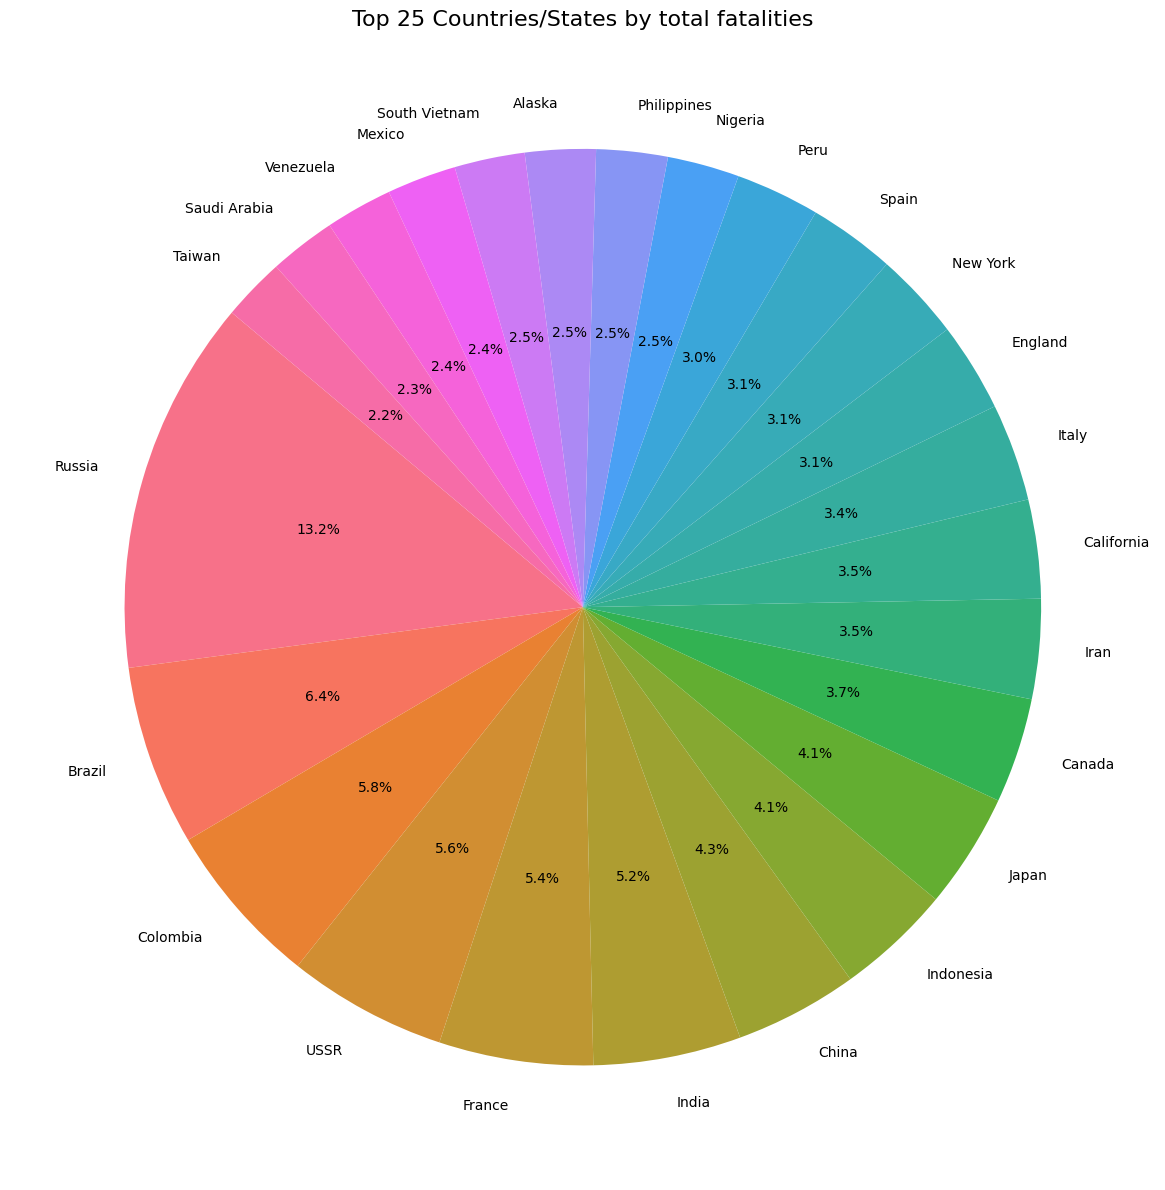

In [31]:
facility_totals = fatality_locations.groupby('US State/Country')['Fatalities'].sum().reset_index()

facility_totals = facility_totals[facility_totals['US State/Country'] != 'Unknown']

top_25 = facility_totals.sort_values(by = 'Fatalities', ascending =False).head(25)

plt.figure(figsize=(12, 12))
plt.title('Top 25 Countries/States by total fatalities', fontsize = 16)

colors = sns.color_palette('husl', 25)

plt.pie(top_25['Fatalities'],
        labels = top_25['US State/Country'],
        autopct = '%1.1f%%',
        startangle = 140,
        colors = colors,
        textprops = {'fontsize': 10})
plt.tight_layout()
plt.show()